# KO Case 01: Limb Mesenchyme Pathway Enrichment with Navigo

This notebook uses Navigo to compare predicted and observed pathway responses after `Gli2` knockout in limb mesenchyme progenitors.

In this notebook you will:
1. Simulate `Gli2` knockout response vectors in limb mesenchyme progenitors.
2. Quantify pathway enrichment from predicted KO-responsive genes.
3. Compare predicted pathway shifts with the observed KO enrichment pattern.

Import required packages and set deterministic seeds.

In [1]:
import json
import sys
from pathlib import Path

import anndata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy.stats import hypergeom

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f'Seed set to {SEED}')

Seed set to 0


Set paths and runtime configuration for this KO case.

In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'docs' / 'tutorials').exists() and (p / 'navigo').exists():
            return p
    raise RuntimeError(f'Could not locate repository root from {start}')


repo_root = find_repo_root(Path.cwd().resolve())
tutorials_root = repo_root / 'docs' / 'tutorials'
notebook_dir = tutorials_root / 'notebooks' / 'knockout_section'
data_root = repo_root / 'data' / 'knockout'
checkpoints_root = repo_root / 'checkpoints' / 'knockout'
case_output_root = tutorials_root / 'outputs' / 'knockout_limb_pathway_enrichment'

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from navigo import run_perturbation_inference

CELL_TYPE = 'Limb#mesenchyme#trajectory'
RUNTIME_CELL_LABEL = CELL_TYPE
TARGET_GENE_ID = 'ENSMUSG00000048402'  # Gli2
KEEP_DAYS = ['E12.5', 'E12.75', 'E13.0', 'E13.25', 'E13.5']

CHECKPOINT_PATH = checkpoints_root / 'limb_mesenchyme_knockout_checkpoint_9.pth'
RAW_DATA_PATH = data_root / 'limb_mesenchyme_trajectory.h5ad'
MSIGDB_PATH = data_root / 'msigdb_mouse_v2025_1.json'
GT_PATHWAY_TABLE = data_root / 'gene_compensation' / 'gli_output' / 'all_pathway_results.csv'

RUNTIME_DIR = case_output_root / '00_runtime_inputs'
INFERRED_DIR = case_output_root / '01_inference_csv'
METRIC_DIR = case_output_root / '02_metrics_tables'
FIGURE_DIR = case_output_root / '03_figures'
for p in [RUNTIME_DIR, INFERRED_DIR, METRIC_DIR, FIGURE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

required = {
    'checkpoint': CHECKPOINT_PATH,
    'raw_data': RAW_DATA_PATH,
    'msigdb': MSIGDB_PATH,
    'groundtruth_table': GT_PATHWAY_TABLE,
}
missing = [f'{k}: {v}' for k, v in required.items() if not v.exists()]
if missing:
    raise FileNotFoundError('Missing required files\n' + '\n'.join(missing))


## Step 1: Simulate Gli2 KO responses with Navigo package API
We subset to `E12.5-E13.5` and run KO inference (`knockout_scale=0.0`) to match zero-expression KO simulation behavior.

In [ ]:
adata_raw = anndata.read_h5ad(RAW_DATA_PATH)
adata_subset = adata_raw[adata_raw.obs['day'].isin(KEEP_DAYS)].copy()
adata_subset.obs['cell_type'] = RUNTIME_CELL_LABEL

subset_h5ad_path = RUNTIME_DIR / '01_limb_mesenchyme_subset_E12.5_to_E13.5.h5ad'
target_list_txt_path = RUNTIME_DIR / '01_targets_used.txt'
adata_subset.write_h5ad(subset_h5ad_path)
target_list_txt_path.write_text(TARGET_GENE_ID + '\n')

inference_summary = run_perturbation_inference(
    data_path=subset_h5ad_path,
    checkpoint_path=CHECKPOINT_PATH,
    target_list_path=target_list_txt_path,
    output_dir=INFERRED_DIR,
    fibro_cell_type=RUNTIME_CELL_LABEL,
    input_dim=7804,
    hidden_1=5012,
    hidden_2=5012,
    flow_num_steps=100,
    simulation_steps=10,
    knockout_scale=0.0,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    strict_target_presence=True,
)

print(f'Target gene: {TARGET_GENE_ID}')
print(f'Inference output folder: {INFERRED_DIR.relative_to(repo_root)}')
print(f"Generated CSV files: {len(list(INFERRED_DIR.glob('*.csv')))}")


## Step 2: Build KO pathway enrichment matrix (prediction vs ground truth)
For each hallmark/reactome pathway, we compute prediction-side enrichment and compare it with curated experimental KO enrichment.

In [4]:
gt_pathway_df = pd.read_csv(GT_PATHWAY_TABLE)
pathway_df = gt_pathway_df[gt_pathway_df['cell_type'].astype(str) == CELL_TYPE].copy()
if pathway_df.empty:
    raise ValueError(f'No pathway rows found for {CELL_TYPE} in {GT_PATHWAY_TABLE}')

short_name_map = {
    'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION': 'EMT',
    'REACTOME_SIGNALING_BY_WNT': 'WNT',
    'REACTOME_SIGNALING_BY_HEDGEHOG': 'Hedgehog',
    'HALLMARK_PI3K_AKT_MTOR_SIGNALING': 'PI3K/Akt/mTOR',
    'HALLMARK_G2M_CHECKPOINT': 'G2M Checkpoint',
    'HALLMARK_TGF_BETA_SIGNALING': 'TGF Beta',
    'HALLMARK_NOTCH_SIGNALING': 'Notch',
    'HALLMARK_APOPTOSIS': 'Apoptosis',
    'HALLMARK_INFLAMMATORY_RESPONSE': 'Inflammatory',
}

pathway_df['pathway_short'] = pathway_df['pathway'].map(short_name_map).fillna(pathway_df['pathway'])
pred_table = pathway_df[['pathway', 'pathway_short', 'p_value_pred', 'neg_log10_p_pred']].copy()
compare_table = pathway_df[[
    'pathway',
    'pathway_short',
    'p_value_pred',
    'neg_log10_p_pred',
    'p_value_real',
    'neg_log10_p_real',
]].copy().sort_values('neg_log10_p_pred', ascending=False).reset_index(drop=True)

matrix = compare_table.set_index('pathway_short')[['neg_log10_p_pred', 'neg_log10_p_real']].rename(
    columns={'neg_log10_p_pred': 'Prediction', 'neg_log10_p_real': 'Ground truth'}
)

pred_out = METRIC_DIR / '01_limb_mesenchyme_prediction_pathway_enrichment.csv'
all_out = METRIC_DIR / '01_all_pathway_results.csv'
matrix_out = METRIC_DIR / '01_limb_mesenchyme_hypergeometric_matrix.csv'
pred_table.to_csv(pred_out, index=False)
compare_table.to_csv(all_out, index=False)
matrix.to_csv(matrix_out)
matrix.round(2)


,Prediction,Ground truth
pathway_short,,
EMT,5.83,1.44
WNT,1.47,3.21
Hedgehog,1.31,2.32
PI3K/Akt/mTOR,1.08,0.41
G2M Checkpoint,0.36,0.36
TGF Beta,-0.00,-0.00
Notch,-0.00,0.84
Apoptosis,-0.00,-0.00
Inflammatory,-0.00,-0.00


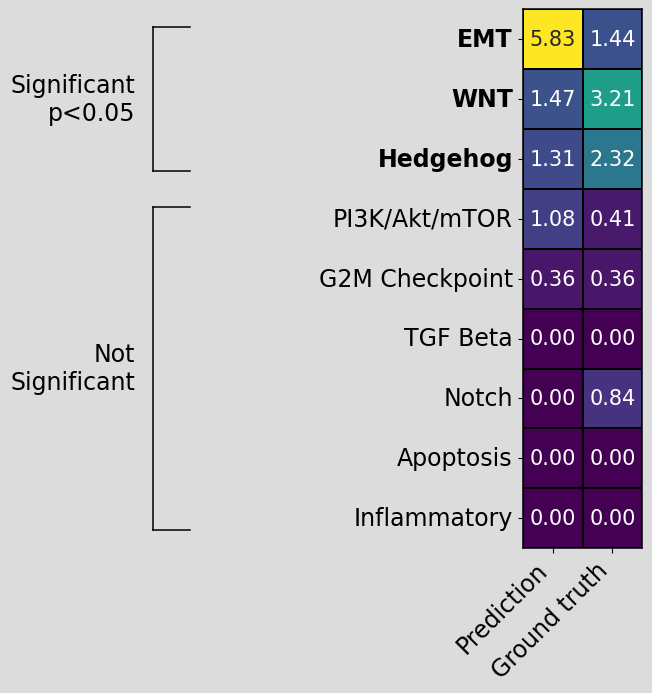

In [5]:
plot_df = matrix.mask(matrix.abs() < 1e-12, 0.0).copy()

fig = plt.figure(figsize=(8.4, 7.0), facecolor='#dcdcdc')
gs = fig.add_gridspec(1, 2, width_ratios=[1.05, 1.15], wspace=0.04)
ax_left = fig.add_subplot(gs[0, 0], facecolor='#dcdcdc')
ax = fig.add_subplot(gs[0, 1], facecolor='#dcdcdc')

sns.heatmap(
    plot_df,
    cmap='viridis',
    annot=True,
    fmt='.2f',
    cbar=False,
    linewidths=1.1,
    linecolor='black',
    square=True,
    annot_kws={'fontsize': 15},
    ax=ax,
)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=17)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=17)
for i, lbl in enumerate(ax.get_yticklabels()):
    if i <= 2:
        lbl.set_fontweight('bold')

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.1)
    spine.set_color('black')

ax_left.set_xlim(0, 1)
ax_left.set_ylim(ax.get_ylim())
ax_left.axis('off')

x0, x1 = 0.18, 0.30
y0, y1 = 0.3, 2.7
ax_left.plot([x0, x1], [y0, y0], color='black', lw=1.1)
ax_left.plot([x0, x1], [y1, y1], color='black', lw=1.1)
ax_left.plot([x0, x0], [y0, y1], color='black', lw=1.1)
ax_left.text(0.12, 1.5, 'Significant\np<0.05', ha='right', va='center', fontsize=17)

y0b, y1b = 3.3, 8.7
ax_left.plot([x0, x1], [y0b, y0b], color='black', lw=1.1)
ax_left.plot([x0, x1], [y1b, y1b], color='black', lw=1.1)
ax_left.plot([x0, x0], [y0b, y1b], color='black', lw=1.1)
ax_left.text(0.12, 6.0, 'Not\nSignificant', ha='right', va='center', fontsize=17)

figure_path = FIGURE_DIR / '01_limb_mesenchyme_pathway_heatmap_replica.png'
fig.savefig(figure_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


## How to read the heatmap
- **Heterogeneous pathway buffering**: KO responses are not uniform across pathways; some programs shift strongly while others remain comparatively buffered.
- **Significant developmental axes**: In this limb mesenchyme case, EMT, WNT, and Hedgehog enrichment are strong, consistent with Gli-driven developmental regulation.
- **Buffered modules**: Lower enrichment in several pathways is compatible with partial compensation in which related programs preserve parts of the regulatory state despite `Gli2` perturbation.
- **Practical takeaway**: Pathway-level agreement between prediction and ground truth shows that response-vector enrichment is a useful readout of KO impact beyond single-gene metrics.